In [1]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.dates as mdates

In [2]:
def load_demand_data():
    path = "/g/data/gb02/ad1803/Hot & Cloudy/Demand Data/"
    hot_demand_days = xr.open_dataset(path+"hot_high_demand_days.nc")
    hot_low_demand_days = xr.open_dataset(path+"hot_low_demand_days.nc")
    return hot_demand_days, hot_low_demand_days

def load_nemosis(path,region=None):

    df = pd.read_csv(path,skiprows=[0])

    if region is None:
        return df
    else:
        df = df[df["REGIONID"]==region]
        df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])
        df = df.set_index("SETTLEMENTDATE").sort_index()
        return df

In [3]:
def load_stn_data(stn_no,t1,t2):
    f = xr.open_mfdataset("/g/data/ng72/ab4502/BoM_data_202409/half_hourly_data_netcdf/AWS-data-VIC.nc")
    t = pd.to_datetime(f.time)
    f["time"] = t.tz_localize("UTC").tz_convert("Australia/Melbourne").tz_localize(None)
    f.sel(station=(f.bmid.values==stn_no),time=slice(t1,t2)).persist().temp.plot()
    return f.sel(station=(f.bmid.values==stn_no),time=slice(t1,t2)).temp.persist()

In [4]:
def load_cloud():

    data_dir = Path('/g/data/gb02/cd3022/hot-and-cloudy/solar-pv/GCCSA/ideal-actual')
    files = list(data_dir.glob("*.nc"))
    datasets = []
    
    for file in files:
        region_name = file.stem[1:5]
        ds_reg = xr.open_dataset(file)
        ds_reg = ds_reg.expand_dims(region=[region_name])
    
        datasets.append(ds_reg)
    
    ds = xr.concat(datasets, dim='region')

    # Change times to AEST
    time_utc = pd.to_datetime(ds.time.values)
    time_aest = time_utc.tz_localize("UTC").tz_convert("Australia/Brisbane")
    time_aest_naive = time_aest.tz_convert("Australia/Brisbane").tz_localize(None)
    ds = ds.assign_coords(time=("time", time_aest_naive))
    
    ds = ds.where(ds['time'].dt.strftime('%H:%M') != '12:40', drop=True)
    
    bad_days = [
        np.datetime64('2019-08-12'),
        np.datetime64('2019-10-01'),
        np.datetime64('2020-09-06'),
        
    ]
    ds_dates = ds['time'].dt.floor('D')
    good_time_mask = ~ds_dates.isin(bad_days)
    ds = ds.sel(time=ds['time'][good_time_mask])
    
    rated_capacity = 219.656729124
    ds = ds.apply(lambda x: x / rated_capacity)
    
    #ds = xr.where(ds.isnull(), 0, ds)

    return ds

def load_cloud_gccsa():

    file_path = Path('/g/data/gb02/cd3022/hot-and-cloudy/solar-pv/GCCSA/')
    
    files = list(file_path.glob(f"*.nc"))
    ds = xr.open_mfdataset(files, combine='nested')

    ds = ds.where(ds['time'].dt.strftime('%H:%M') != '12:40', drop=True)

    bad_days = [
        np.datetime64('2019-08-12'),
        np.datetime64('2019-10-01'),
        np.datetime64('2020-09-06'),
        
    ]
    ds_dates = ds['time'].dt.floor('D')
    good_time_mask = ~ds_dates.isin(bad_days)
    ds = ds.sel(time=ds['time'][good_time_mask])

    # Rated capacity taken from sandia_modules['Canadian_Solar_CS5P_220M___2009_'], solar panel used in pvlib system,
    # using the calculation rated_capacity = module.loc['Impo'] * module.loc['Vmpo']
    rated_capacity = 219.656729124
    ds = ds.apply(lambda x: x / rated_capacity) # raw data can be used for load duration curves, before morning/evening data is removed in "clip_dusk_dawn"

    ds = xr.where(ds.isnull(), 0, ds)

    return ds

In [5]:
#Load temperature data for high/low demand days from Alex
temps, temps_low = load_demand_data()

#Load solar CF data from Carl
cloud = load_cloud()

#Load Carl's previous dataset
cloud_orig = load_cloud_gccsa()

In [6]:
#Subset solar CF data to Melbourne, between 6 am and 9 pm, during DJFM
cloud = cloud.sel(region="GMEL",time=(cloud.time.dt.hour>=6) & (cloud.time.dt.hour<=21) & (np.in1d(cloud.time.dt.month,[12,1,2,3])))

In [7]:
#Resample capacity factors to daily mean, and calculate clear sky index
daily_cloud = cloud.groupby("time.date").mean()
daily_csi = daily_cloud.actual / daily_cloud.ideal

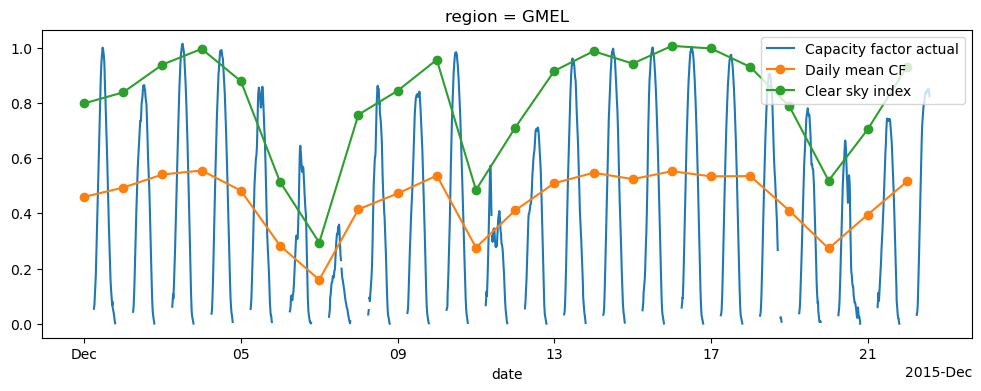

In [8]:
#Plot for a month or so to make sure everything is fine

plt.figure(figsize=[12,4])

cloud.isel(time=slice(0,2000)).actual.plot(label="Capacity factor actual")

daily_cloud.actual.isel(date=slice(0,22)).plot(marker="o",label="Daily mean CF")
daily_csi.isel(date=slice(0,22)).plot(marker="o",label="Clear sky index")

plt.legend()

<Axes: >

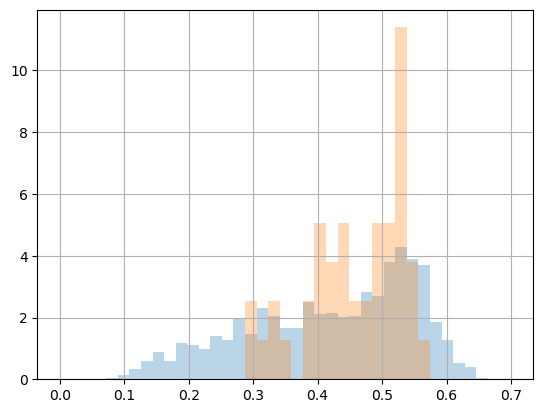

In [9]:
#Replicate Alex's histogram plot for Melbourne to make sure everything is fine

daily_cloud.sel(date=np.in1d(pd.to_datetime(daily_cloud.date).month,[12,1,2,3])).actual.to_pandas().hist(density=True,alpha=0.3,bins=np.linspace(0,0.7,40))
daily_cloud.sel(date=temps.sel(region="VIC").dropna("time").time).actual.to_pandas().hist(density=True,alpha=0.3,bins=np.linspace(0,0.7,40))

In [10]:
#Combine the temperature and solar CF datset

merged = pd.merge(
    temps.sel(region="VIC").tasmax.dropna("time").to_pandas(),
    daily_cloud.sel(date=temps.sel(region="VIC").dropna("time").time).actual.to_pandas(),
    left_index=True,
    right_index=True).sort_values("actual")

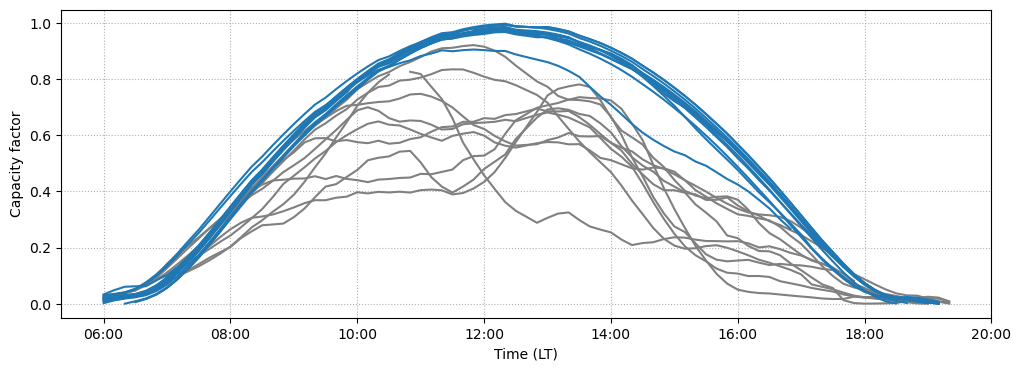

In [11]:
#Plot the top 10 cloudies and top 10 clearest (hot, high demand) days in terms of CF

cloudy_dates = pd.to_datetime(merged.index[0:10]).date

clear_dates = pd.to_datetime(merged.index[-10:]).date

times = cloud.sel(time=np.in1d(cloud.time.dt.date,clear_dates[0])).time


plt.figure(figsize=[12,4])


[plt.plot(times,cloud.sel(time=cloud.time.dt.date ==d).actual.values,color="grey") for d in cloudy_dates]
[plt.plot(times,cloud.sel(time=cloud.time.dt.date ==d).actual.values,color="tab:blue") for d in clear_dates]

plt.plot(times,cloud.sel(time=cloud.time.dt.date == dt.date(2020,1,30)).actual.values)


myFmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)

plt.xlabel("Time (LT)")
plt.ylabel("Capacity factor")

plt.gca().grid(ls=":")

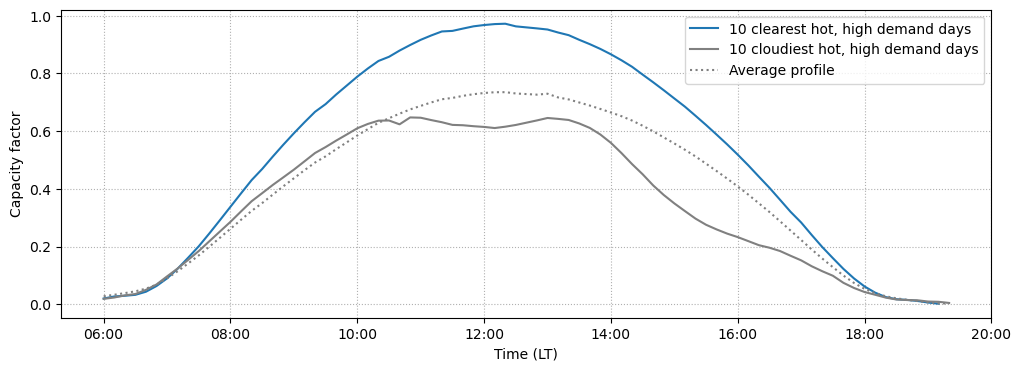

In [12]:
#Plot the average daily profile of the top 10 cloudy and top 10 clearest hot high demand days. Compare with average profile over the entire 9-year period

plt.figure(figsize=[12,4])

times = cloud.sel(time=np.in1d(cloud.time.dt.date,clear_dates[0])).time

plt.plot(
    times,
    cloud.sel(time=np.in1d(cloud.time.dt.date,clear_dates)).groupby("time.time").mean().actual,
    label="10 clearest hot, high demand days")
plt.plot(
    times,
    cloud.sel(time=np.in1d(cloud.time.dt.date,cloudy_dates)).groupby("time.time").mean().actual,
    color="grey",label="10 cloudiest hot, high demand days")

plt.plot(
    times,
    cloud.groupby("time.time").mean().actual,
    color="grey",ls=":",label="Average profile")

plt.legend()



myFmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)

plt.xlabel("Time (LT)")
plt.ylabel("Capacity factor")

plt.gca().grid(ls=":")

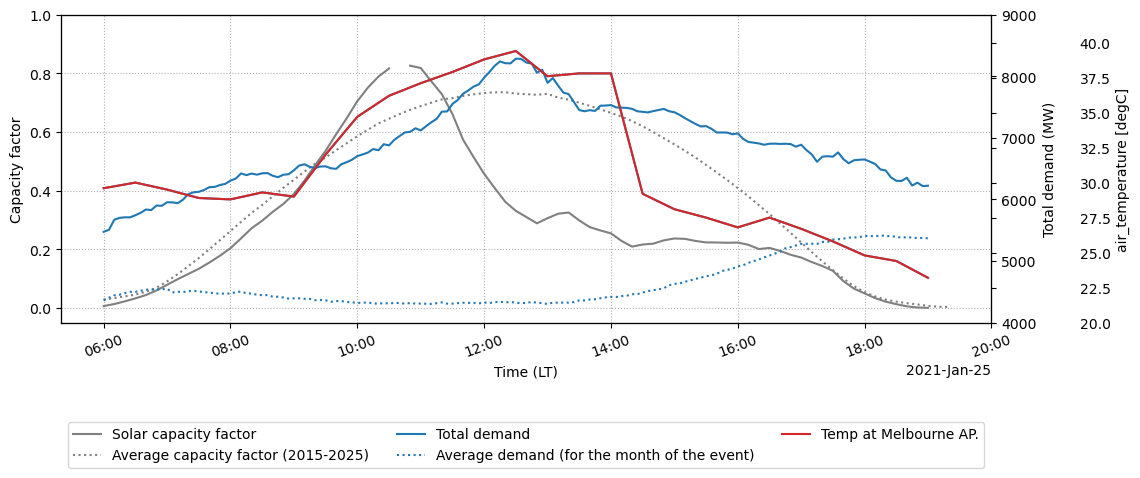

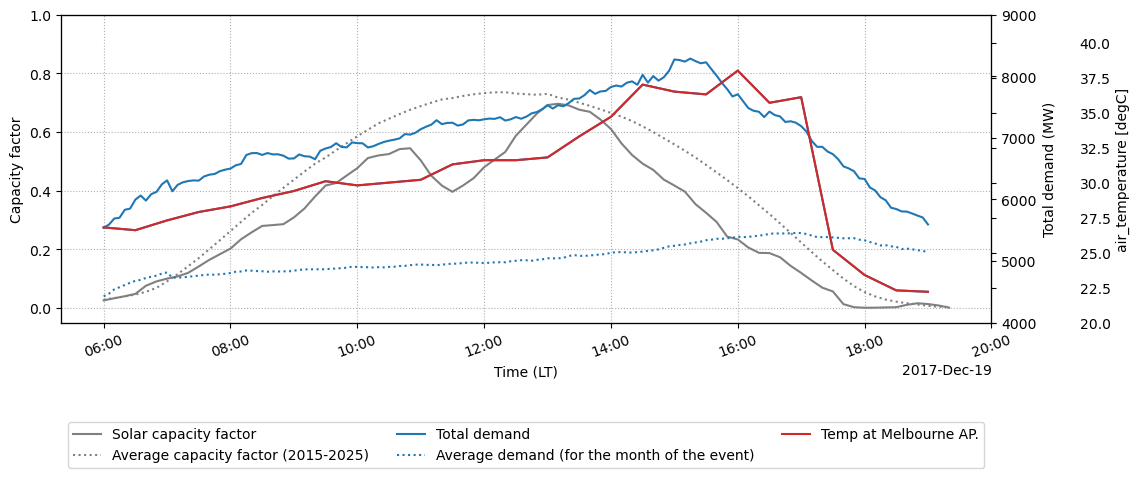

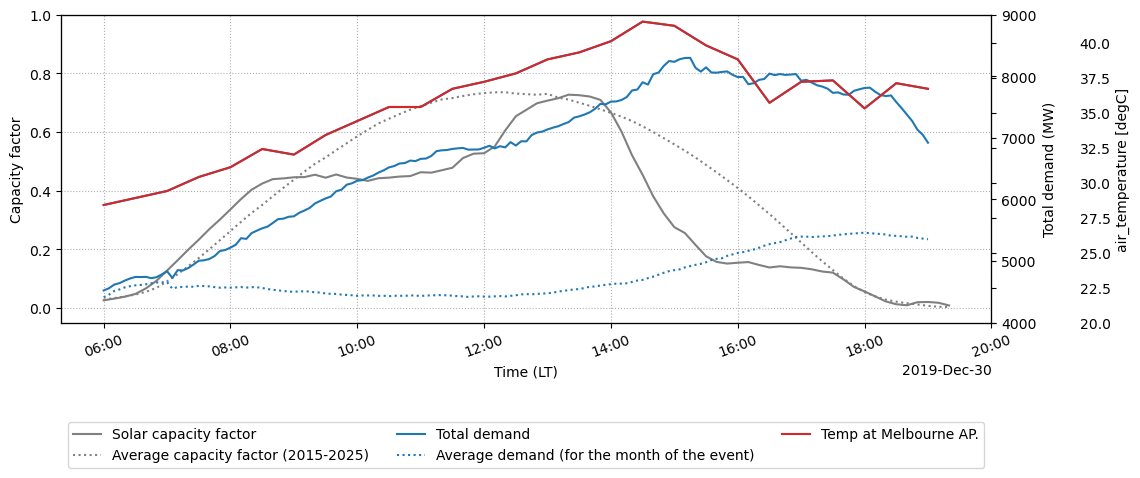

In [13]:
def plot_ts(date, path, t1, t2):

    plt.figure(figsize=[12,4])
    
    ax=plt.axes()
    
    l1=ax.plot(
        pd.DatetimeIndex(cloud.sel(time=np.in1d(cloud.time.dt.date,date)).time),
        cloud.sel(time=np.in1d(cloud.time.dt.date,date)).actual,
        color="grey")
    l2=ax.plot(
        cloud.sel(time=np.in1d(cloud.time.dt.date,date)).time,
        cloud.groupby("time.time").mean().actual,
        color="grey",ls=":",label="Average profile")
    
    plt.ylim([-0.05,1])
    
    ax2=ax.twinx()
    
    df = load_nemosis(path,"VIC1")["TOTALDEMAND"]
    df = df[~df.index.duplicated(keep='first')]
    
    l3=ax2.plot(
        df.loc[slice(t1,t2)].index,
        df.loc[slice(t1,t2)].values,
        color="tab:blue")
    l4=ax2.plot(
        df.loc[slice(t1,t2)].index,
        df.groupby(df.index.time).mean().iloc[72:-59],
        color="tab:blue",ls=":")
    
    
    myFmt = mdates.DateFormatter('%Y-%m-%d %H:%M')
    ax.xaxis.set_major_formatter(myFmt)
    ax.tick_params("x",rotation=20)
    
    ax.set_xlabel("Time (LT)")
    ax.set_ylabel("Capacity factor")
    
    ax.grid(ls=":")

    ax2.set_ylabel("Total demand (MW)")

    ax3 = ax.twinx()
    l5=load_stn_data(86282,t1,t2).plot(color="tab:red")
    ax3.tick_params("y",pad=60)

    ax2.set_ylim([4000,9000])
    ax3.set_ylim([20,42])

    plt.legend([l1[0],l2[0],l3[0],l4[0],l5[0]],
               ["Solar capacity factor","Average capacity factor (2015-2025)","Total demand","Average demand (for the month of the event)","Temp at Melbourne AP."],
              ncols=3,bbox_to_anchor=(1,-0.3))

#Plot time series for some interesting days


plot_ts(
    cloudy_dates[0],
    "/g/data/ng72/ab4502/nemosis/PUBLIC_DVD_DISPATCHREGIONSUM_202101010000.CSV",
    "2021-01-25 06:00",
    "2021-01-25 19:00")

plot_ts(
    cloudy_dates[1],
    "/g/data/ng72/ab4502/nemosis/PUBLIC_DVD_DISPATCHREGIONSUM_201712010000.CSV",
    "2017-12-19 06:00",
    "2017-12-19 19:00")

plot_ts(
    cloudy_dates[2],
    "/g/data/ng72/ab4502/nemosis/PUBLIC_DVD_DISPATCHREGIONSUM_201912010000.CSV",
    "2019-12-30 06:00",
    "2019-12-30 19:00")


